In [1]:
import os
import json
import glob
import torch
import numpy as np
from collections import defaultdict, Counter
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
import matplotlib.pyplot as plt

DISCRIMINATIVE_CACHE_DIRS = [
    "/kaggle/input/datasets/nocturnalnerd18/discriminative-cache-pope",
    "/kaggle/input/datasets/nocturnalnerd18/discriminative-cache-amber",
    "/kaggle/input/datasets/nocturnalnerd18/discriminative-cache-reefknot",
]

cache_by_key = {}
for d in DISCRIMINATIVE_CACHE_DIRS:
    for path in glob.glob(os.path.join(d, "*.pt")):
        batch = torch.load(path)
        for entry in batch:
            cache_by_key[(entry["image_id"], entry["question_id"])] = entry

print(len(cache_by_key), "cached discriminative entries loaded")

N_HIDDEN_LAYERS = next(iter(cache_by_key.values()))["pooled_hidden_states"].shape[0]
print(N_HIDDEN_LAYERS, "hidden-state layers per question (embedding + 32 transformer layers)")

13230 cached discriminative entries loaded
33 hidden-state layers per question (embedding + 32 transformer layers)


In [2]:
with open("/kaggle/input/datasets/nocturnalnerd18/vlm-labeled-examples/labeled_examples.json") as f:
    labeled = json.load(f)
print(len(labeled), "labeled examples")

SPLIT_FILES = {
    "pope_": "/kaggle/input/datasets/nocturnalnerd18/vlm-splits/pope_split.json",
    "amber_": "/kaggle/input/datasets/nocturnalnerd18/vlm-splits/amber_split.json",
    "reefknot_": "/kaggle/input/datasets/nocturnalnerd18/vlm-splits/reefknot_split.json",
}
splits_by_prefix = {}
for prefix, path in SPLIT_FILES.items():
    with open(path) as f:
        splits_by_prefix[prefix] = json.load(f)


def get_split(question_id, image_id):
    for prefix, split_map in splits_by_prefix.items():
        if question_id.startswith(prefix):
            return split_map.get(image_id, "unknown")
    return "unknown"


joined = []
missing_cache = 0
for l in labeled:
    entry = cache_by_key.get((l["image_id"], l["question_id"]))
    if entry is None:
        missing_cache += 1
        continue
    joined.append({
        "image_id": l["image_id"],
        "question_id": l["question_id"],
        "hallucination_type": l["hallucination_type"],
        "correct": l["correct"],
        "ground_truth_answer": l["ground_truth_answer"],
        "pooled_hidden_states": entry["pooled_hidden_states"],
        "pooled_encoder_embedding": entry["pooled_encoder_embedding"],
        "split": get_split(l["question_id"], l["image_id"]),
    })

print(len(joined), "joined,", missing_cache, "labeled examples had no matching cache entry")
print(Counter(j["hallucination_type"] for j in joined))
print(Counter(j["split"] for j in joined))

13222 labeled examples
13222 joined, 0 labeled examples had no matching cache entry
Counter({'attribute': 7620, 'object': 3000, 'relation': 2602})
Counter({'train': 9251, 'val': 2002, 'test': 1969})


In [3]:
def build_layer_dataset(subset, layer_idx, split_name):
    X, y = [], []
    for j in subset:
        if j["split"] != split_name:
            continue
        X.append(j["pooled_hidden_states"][layer_idx].float().numpy())
        y.append(0 if j["correct"] else 1)  # 1 = hallucinated
    return np.array(X), np.array(y)


results = defaultdict(list)  # hallucination_type -> [(layer, val_acc, baseline_acc), ...]

for h_type in ["object", "attribute", "relation"]:
    subset = [j for j in joined if j["hallucination_type"] == h_type]
    print(f"--- {h_type}: {len(subset)} examples ---")

    for layer in range(N_HIDDEN_LAYERS):
        X_train, y_train = build_layer_dataset(subset, layer, "train")
        X_val, y_val = build_layer_dataset(subset, layer, "val")

        if len(set(y_train)) < 2 or len(X_val) == 0:
            continue

        clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear"))
        clf.fit(X_train, y_train)
        val_acc = val_acc = balanced_accuracy_score(y_val, clf.predict(X_val))

        majority_class = Counter(y_val).most_common(1)[0][0]
        baseline_acc = 0.5

        results[h_type].append((layer, val_acc, baseline_acc))

    if not results[h_type]:
        print("  not enough data to train any probes for this type")

--- object: 3000 examples ---
--- attribute: 7620 examples ---
--- relation: 2602 examples ---


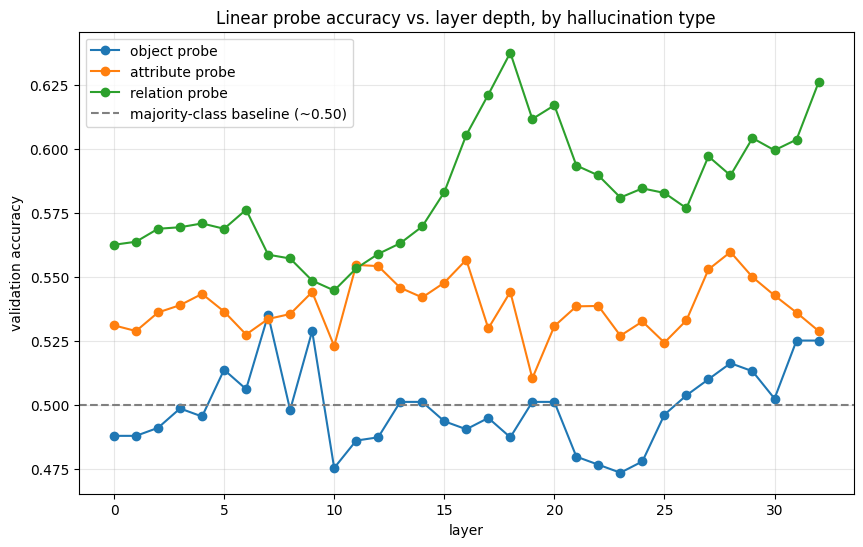

In [4]:
plt.figure(figsize=(10, 6))
for h_type, rows in results.items():
    if not rows:
        continue
    layers = [r[0] for r in rows]
    val_accs = [r[1] for r in rows]
    plt.plot(layers, val_accs, marker="o", label=f"{h_type} probe")

if results.get("object"):
    baseline = results["object"][0][2]
    plt.axhline(baseline, color="gray", linestyle="--", label=f"majority-class baseline (~{baseline:.2f})")

plt.xlabel("layer")
plt.ylabel("validation accuracy")
plt.title("Linear probe accuracy vs. layer depth, by hallucination type")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("/kaggle/working/probe_accuracy_by_layer.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
for h_type in ["object", "attribute", "relation"]:
    subset = [j for j in joined if j["hallucination_type"] == h_type]
    print(h_type, Counter(j["correct"] for j in subset))

object Counter({True: 2681, False: 319})
attribute Counter({True: 5595, False: 2025})
relation Counter({True: 1561, False: 1041})


In [6]:
import numpy as np
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

def fit_and_score(X_tr, y_tr, X_val, y_val):
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear"))
    clf.fit(X_tr, y_tr)
    return balanced_accuracy_score(y_val, clf.predict(X_val))

In [7]:
CHECK_LAYERS = [0, 4, 10, 14, 18, 22, 28, 32]
N_RESAMPLES = 10

In [8]:
robust_results = defaultdict(list)

for h_type in ["object", "attribute", "relation"]:
    subset = [j for j in joined if j["hallucination_type"] == h_type]
    for layer in CHECK_LAYERS:
        X_train, y_train = build_layer_dataset(subset, layer, "train")
        X_val, y_val = build_layer_dataset(subset, layer, "val")
        if len(set(y_train)) < 2 or len(X_val) == 0:
            continue

        # bootstrap: resample the real training set with replacement -- how stable is this result?
        real_scores = [
            fit_and_score(X_train[idx], y_train[idx], X_val, y_val)
            for idx in (np.random.choice(len(X_train), len(X_train), replace=True) for _ in range(N_RESAMPLES))
        ]

        # permutation: shuffle the labels, destroying any real relationship -- what does pure chance look like at this exact sample size?
        null_scores = [
            fit_and_score(X_train, np.random.permutation(y_train), X_val, y_val)
            for _ in range(N_RESAMPLES)
        ]

        robust_results[h_type].append((layer, np.mean(real_scores), np.std(real_scores), np.mean(null_scores), np.std(null_scores)))
    print(h_type, "done,", len(robust_results[h_type]), "layers")

object done, 8 layers
attribute done, 8 layers
relation done, 8 layers


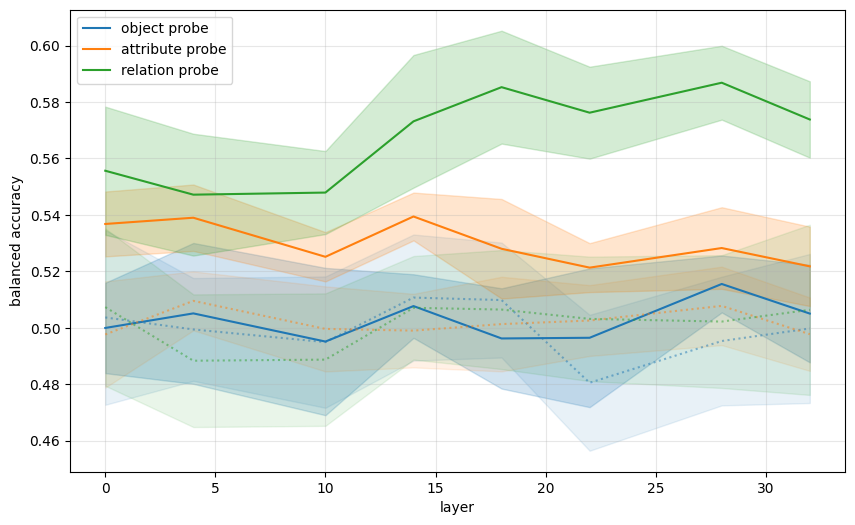

In [9]:
colors = {"object": "tab:blue", "attribute": "tab:orange", "relation": "tab:green"}
plt.figure(figsize=(10, 6))
for h_type, rows in robust_results.items():
    layers = [r[0] for r in rows]
    real_mean, real_std = np.array([r[1] for r in rows]), np.array([r[2] for r in rows])
    null_mean, null_std = np.array([r[3] for r in rows]), np.array([r[4] for r in rows])
    c = colors[h_type]
    plt.plot(layers, real_mean, label=f"{h_type} probe", color=c)
    plt.fill_between(layers, real_mean - real_std, real_mean + real_std, alpha=0.2, color=c)
    plt.plot(layers, null_mean, linestyle=":", color=c, alpha=0.5)
    plt.fill_between(layers, null_mean - null_std, null_mean + null_std, alpha=0.1, color=c)
plt.xlabel("layer"); plt.ylabel("balanced accuracy"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [10]:
os.makedirs("/kaggle/working/probing_results", exist_ok=True)

with open("/kaggle/working/probing_results/probe_accuracy_by_layer.json", "w") as f:
    json.dump({h_type: rows for h_type, rows in results.items()}, f)
with open("/kaggle/working/probing_results/robustness_check.json", "w") as f:
    json.dump({h_type: rows for h_type, rows in robust_results.items()}, f)

with open("/kaggle/working/probing_results/dataset-metadata.json", "w") as f:
    json.dump({
        "title": "vlm-probing-results",
        "id": "nocturnalnerd18/vlm-probing-results",
        "licenses": [{"name": "CC0-1.0"}]
    }, f)

!kaggle datasets create -p /kaggle/working/probing_results/

Starting upload for file robustness_check.json
100%|██████████████████████████████████████| 2.12k/2.12k [00:00<00:00, 5.65kB/s]
Upload successful: robustness_check.json (2KB)
Starting upload for file probe_accuracy_by_layer.json
100%|██████████████████████████████████████| 2.96k/2.96k [00:00<00:00, 8.44kB/s]
Upload successful: probe_accuracy_by_layer.json (3KB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/nocturnalnerd18/vlm-probing-results
